# Preprocessing

Cleans the data, drops weak features found in EDA, scales Amount and Time, splits into train and test, and builds a few versions of the training set using different strategies for the class imbalance.

In [2]:
#loading and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')


Loading the raw data.

In [3]:
#load the data
df=pd.read_csv("../data/creditcard.csv")
print(f"original dataset shape:{df.shape}")
print(f"fraud count:{df['Class'].sum()}")


original dataset shape:(284807, 31)
fraud count:492


In [4]:
#check for missing values
print(f"number of missing values:{df.isnull().sum().sum()}")


number of missing values:0


Removing duplicate rows.

In [5]:
#Remove Duplicates
before=len(df)
print(f"number of duplicated instances:{df.duplicated().sum()}")
df.drop_duplicates(inplace=True)#or df=df.drop_duplicates()
after=len(df)
print(f"removed instances:{before-after}")
print(f"old shape:{before}\nnew shape:{after}")

number of duplicated instances:1081
removed instances:1081
old shape:284807
new shape:283726


Dropping weak features found in EDA, and scaling Amount and Time. The PCA features (V1-V28) are already scaled from the original PCA transform.

In [6]:
#feature engineering
#first drop weak features identified in EDA
weak_features = ['V13', 'V15', 'V22']
df=df.drop(columns=weak_features)
print(f"Dropped weak features: {weak_features}")
# feature scaling, PCA features are already scaled
scaler=RobustScaler()
df["Amount_scaled"]=scaler.fit_transform(df[["Amount"]])
df["Time_scaled"]=scaler.fit_transform(df[["Time"]])
df.drop(columns=["Amount","Time"],inplace=True)


Dropped weak features: ['V13', 'V15', 'V22']


In [7]:
print(f"final features set:{df.shape[1]}")
print(f"Features: {df.columns.tolist()}")


final features set:28
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']


Splitting into train and test, stratified on the fraud label so both sets keep the same fraud ratio.

In [8]:
#train_test split
# Separate features and target
X=df.drop("Class",axis=1)
y=df["Class"]
print(f"Features shape: {X.shape}")
print("1 = fraud, 0 = legitimate")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (283726, 27)
1 = fraud, 0 = legitimate
Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #Stratified Split
    #Preserves 0.17% fraud ratio in BOTH train and test
    #critical for imbalanced data  
)

In [10]:
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.4f}%")

Train shape: (226980, 27)
Test shape: (56746, 27)
Train fraud rate: 0.1665%
Test fraud rate:  0.1674%


Comparing a few ways to handle the class imbalance: no sampling, SMOTE oversampling, random undersampling, and SMOTETomek, which combines both.

In [11]:
# compare sampling strategies for the training data
# to deal with imbalanced data
def class_distribution(y,title):
    counts=pd.Series(y).value_counts()
    print(f"\n{title}")
    print(f"Legitimate: {counts[0]:,}")
    print(f"Fraud:      {counts[1]:,}")
    print(f"Fraud ratio:{(counts[1]/(counts[0]+counts[1]))*100}%")
    print(f"Ratio:      {counts[0]/counts[1]:.0f}:1")
   
    


In [12]:
#No sampling (baseline)
class_distribution(y_train, "No Sampling")


No Sampling
Legitimate: 226,602
Fraud:      378
Fraud ratio:0.16653449643140364%
Ratio:      599:1


In [13]:
#SMOTE oversampling
smote=SMOTE(random_state=42,k_neighbors=5)
X_smote,y_smote=smote.fit_resample(X_train, y_train)
class_distribution(y_smote, "SMOTE oversampling")


SMOTE oversampling
Legitimate: 226,602
Fraud:      226,602
Fraud ratio:50.0%
Ratio:      1:1


In [14]:
#Random undersampling
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
X_under, y_under = rus.fit_resample(X_train, y_train)
class_distribution(y_under, "Random undersampling")



Random undersampling
Legitimate: 756
Fraud:      378
Fraud ratio:33.33333333333333%
Ratio:      2:1


In [15]:
#SMOTETomek (combined) oversampling+undersampling
smt = SMOTETomek(random_state=42)
X_combined, y_combined = smt.fit_resample(X_train, y_train)
class_distribution(y_combined, "SMOTETomek")



SMOTETomek
Legitimate: 226,602
Fraud:      226,602
Fraud ratio:50.0%
Ratio:      1:1


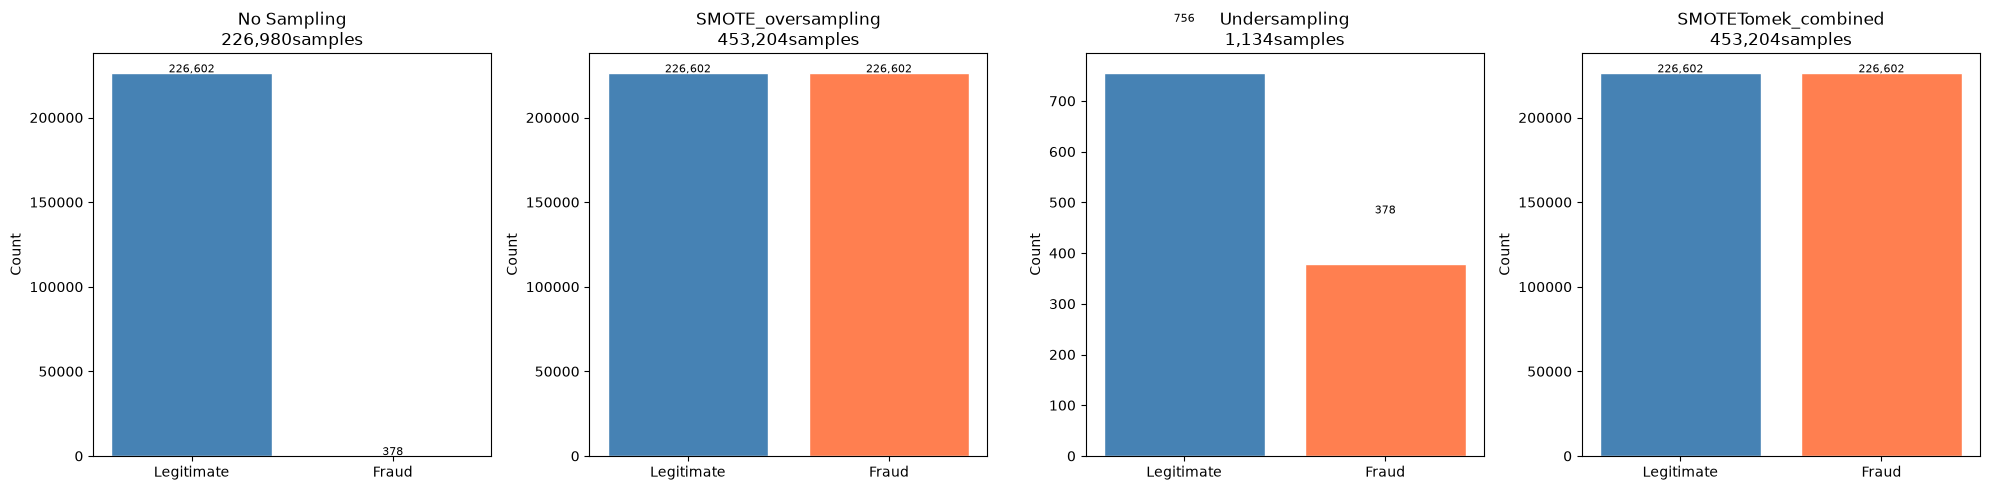

In [16]:
# Visualize Sampling Results
fig,axes=plt.subplots(1,4,figsize=(20,5))

strategies=[('No Sampling', y_train),
            ('SMOTE_oversampling', y_smote),
            ('Undersampling', y_under),
            ('SMOTETomek_combined', y_combined)
            ]
for i ,(name,y) in enumerate(strategies):
    counts=pd.Series(y).value_counts()
    axes[i].bar(["Legitimate","Fraud"],
                counts.values,
                color=['steelblue', 'coral'],
                edgecolor='white')
    axes[i].set_title(f"{name}\n{len(y):,}samples")
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, f'{v:,}',
                    ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../results/sampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Saving the test set and all training set versions for the modeling notebook.

In [17]:
# save datasets
# saving test data
X_test.to_csv("../data/X_test.csv",index=False)
y_test.to_csv("../data/y_test.csv",index=False)



In [18]:
# saving all the training versions

X_train.to_csv("../data/X_train.csv",index=False)
y_train.to_csv("../data/y_train.csv",index=False)




In [19]:
pd.DataFrame(X_smote,columns=X_train.columns).to_csv(
    "../data/X_train_smote.csv",index=False
)
pd.Series(y_smote).to_csv(
    "../data/y_train_smote.csv",index=False)

In [20]:
pd.DataFrame(X_under,columns=X_train.columns).to_csv(
    "../data/X_train_under.csv",index=False
)
pd.Series(y_under).to_csv(
    "../data/y_train_under.csv",index=False)

In [21]:
pd.DataFrame(X_combined,columns=X_train.columns).to_csv(
    "../data/X_train_combined.csv",index=False
)
pd.Series(y_combined).to_csv(
    "../data/y_train_combined.csv",index=False)